# Hackaton 2024 - 2025

## Les Koalas d'Australie vous présentent leur projet de prédictions de catastrophes naturelles à Toulouse en 2180

## Notre équipe
- ROELENS Jean (Chef d'équipe)
- ANDRAWS Pascal
- GUELL Marine
- GUESMI Isra
- LAMBERT Louis
- MAIMOUNI Mouhcine
- RIGAL Nino

## Contexte
En 2180, la mégapole qu'est devenue Toulouse est sujette à de violentes catastrophe naturelles qui détruisent la ville. Heureusement un groupe de jeunes experts se sont ligués pour protégé la ville rose des inondations, tremblements de terre, hackers et autres cataclysmes. Chaque unité à sa manière a pu mettre en place une solution IT pour couvrir l'ensemble des menaces possibles.

Nous sommes les koalas d'Australie, un groupe spécialisé en Data science et nous avons choisi de créer un modèle servant à prédire les inondations et les tremblements de terres qui secouent les Toulousains.

Bienvenue dans notre projet

D'autres équipes Toulousaines nous ont fournie des données, mais ils nous ont aussi informés qu'il fallait apporter quelques modifications avant de pouvoir les utiliser.

In [60]:
import pandas as pd
from pprint import pprint
import csv

In [61]:
# Chemin vers le fichier CSV
input_file = "catastrophes_naturelles(1).csv"
output_file = "clean_catastrophes_naturelles(1).csv"

def initial_cleaning(chemin_fichier, chemin_sortie):
    try:
        # Ouvrir et lire le fichier d'entrée
        with open(chemin_fichier, 'r', encoding='utf-8') as fichier:
            contenu = fichier.read()

        # Supprimer les guillemets
        clean_contenu = contenu.replace('"', '')

        clean_contenu = clean_contenu.replace('aucun', '0')
        clean_contenu = clean_contenu.replace("['seisme']", '1')
        clean_contenu = clean_contenu.replace("['innondation']", '2')
        clean_contenu = clean_contenu.replace("['innondation', 'seisme']", '3')

        clean_contenu = clean_contenu.replace("Zone 1", '1')
        clean_contenu = clean_contenu.replace("Zone 2", '3')
        clean_contenu = clean_contenu.replace("Zone 3", '4')
        clean_contenu = clean_contenu.replace("Zone 4", '2')
        clean_contenu = clean_contenu.replace("Zone 5", '5')

        # Sauvegarder le contenu modifié dans un nouveau fichier
        with open(chemin_sortie, 'w', encoding='utf-8') as fichier_sortie:
            fichier_sortie.write(clean_contenu)

        print(f"Le fichier modifié est enregistré dans : {chemin_sortie}")

    except FileNotFoundError:
        print("Le fichier spécifié est introuvable.")
    except Exception as e:
        print(f"Une erreur est survenue : {e}")

# Appel de la fonction
initial_cleaning(input_file, output_file)

Le fichier modifié est enregistré dans : clean_catastrophes_naturelles(1).csv


Le fichier est prêt pour commencer. Notre première étape consiste à se familiariser avec les données, pour ça nous allons utiliser plusieurs indicateurs.

In [62]:
# Attempt to read the file with a specific encoding
try:
    data = pd.read_csv(output_file,encoding='latin-1', sep=',')
    pprint("Aperçu des 5 premières lignes du dataset :")
    pprint(data.head())
except UnicodeDecodeError as e:
    pprint(f"UnicodeDecodeError: {e}")
except FileNotFoundError as e:
    pprint(f"FileNotFoundError raised with : {e}")

'Aperçu des 5 premières lignes du dataset :'
   Unnamed: 0  temperature  humidite  force_moyenne_du_vecteur_de_vent  \
0           0          5.7      75.6                               3.8   
1           1          5.7      75.6                               3.8   
2           2          5.7      75.6                               3.8   
3           3          5.7      75.6                               3.8   
4           4          5.7      75.6                               3.8   

   force_du_vecteur_de_vent_max  pluie_intensite_max        date  quartier  \
0                           4.3                  0.0  2170-01-01         1   
1                           4.3                  0.0  2170-01-01         3   
2                           4.3                  0.0  2170-01-01         4   
3                           4.3                  0.0  2170-01-01         2   
4                           4.3                  0.0  2170-01-01         5   

   sismicite  concentration_gaz  pluie_to

Shape

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [63]:
data.shape

(3395, 12)

Features

In [64]:
data.columns

Index(['Unnamed: 0', 'temperature', 'humidite',
       'force_moyenne_du_vecteur_de_vent', 'force_du_vecteur_de_vent_max',
       'pluie_intensite_max', 'date', 'quartier', 'sismicite',
       'concentration_gaz', 'pluie_totale', 'catastrophe'],
      dtype='object')

Dtypes per features

In [65]:
data.dtypes

Unnamed: 0                            int64
temperature                         float64
humidite                            float64
force_moyenne_du_vecteur_de_vent    float64
force_du_vecteur_de_vent_max        float64
pluie_intensite_max                 float64
date                                 object
quartier                              int64
sismicite                           float64
concentration_gaz                   float64
pluie_totale                        float64
catastrophe                           int64
dtype: object

Get overview

In [66]:
data.describe()

,Unnamed: 0,temperature,humidite,force_moyenne_du_vecteur_de_vent,force_du_vecteur_de_vent_max,pluie_intensite_max,quartier,sismicite,concentration_gaz,pluie_totale,catastrophe
count,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000
mean,1697.000000,23.101178,56.239175,5.796907,11.547275,0.008100,3.000000,0.648162,194.305184,462.217620,1.102209
std,980.196409,10.415629,13.473980,3.366256,7.004531,0.031777,1.414422,0.178118,53.029867,271.815926,1.011940
min,0.000000,-29.700000,13.400000,1.100000,0.000000,0.000000,1.000000,0.300000,100.080000,0.100000,0.000000
25%,848.500000,15.700000,46.700000,3.500000,6.900000,0.000000,2.000000,0.525000,155.320000,229.500000,0.000000
50%,1697.000000,21.300000,58.200000,4.700000,10.300000,0.000000,3.000000,0.640000,186.900000,457.730000,1.000000
75%,2545.500000,31.300000,66.500000,6.900000,14.600000,0.000000,4.000000,0.790000,236.815000,681.785000,2.000000
max,3394.000000,46.300000,84.700000,32.300000,57.600000,0.300000,5.000000,1.000000,299.900000,999.870000,3.000000


We're lucky because we got no features with *string* but date we'll be an issue when drawing the correlation matrix we're going to drop it.

Nous avons besoin de faire une matrice de corrélation, pour cela nous allons devoir nous séparer de la colonne date.

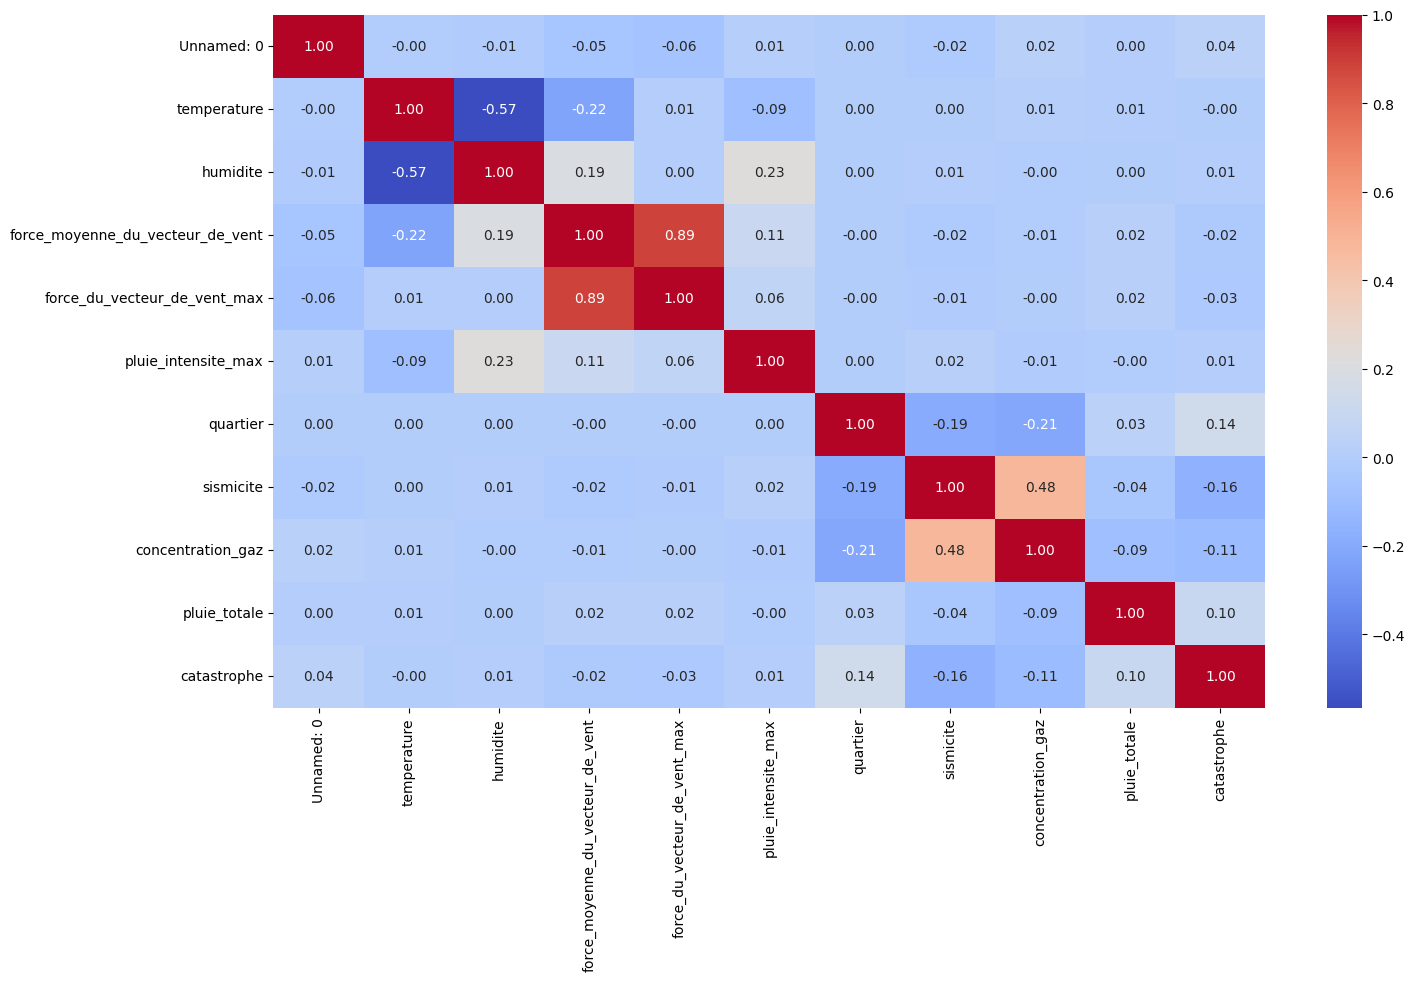

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

data = data.drop(columns=['date'])

plt.figure(figsize=(16,9))
sns.heatmap(data.corr(), cmap='coolwarm',annot=True, fmt=".2f")
plt.show()

Nos observations nous ont permit de mieux comprendre les données à notre disposition. Notre dataset est composé de 3995 lignes elles même composées de 13 colonnes. Notre objecifs étant de prédire la valeur de la dernière colonne cela signifie que nous avons donc 11 features à notre disposition pour tenter de prédire ces catastrophes. En effet, nous n'utiliserons pas la première colonne qui est juste l'identifiant de la ligne.

# Ajouter une phrase à propos de la matrice de corrélation

Les données qui nous sont fournies sont fournies pour nous entrainer sont complète, mais nous avons été prévenues par les groupes en charge de leur récupération qu'elles ne serons pas toujours aussi fournies, nous prévoyons donc de nous séparer des colonnes qui ne pourront pas nous être fournies à l'avenir.

Commençons tout de même par utiliser toutes les données à notre disposition

## Data analysis

Since we're working with two IOT teams we learned that they can't provide us much information so we are gonna drop (later) some columns which will be not be given by IOT's metrics.

## Models

But before dropping some features we want to try with every data that are available.

In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [30]:
# # Step 0 : reload the file to go from a fresh start :
# train_file_path = 'catastrophes_naturelles_vf.csv'
# data = pd.read_csv(train_file_path, delimiter=';')

# data['quartier'].replace(
#     ["Zone 1", "Zone 2", "Zone 3", "Zone 4", "Zone 5"], ["1", "3", "4", "2", "5"]
# )
# data.describe()

In [31]:
# # Step 1 add column 'Event' which sum 'seisme' and 'innondation'
# data['Event'] = 0  # Set column all value to 0 which means 'no events'

# data.loc[(data['seisme'] == 1) & (data['Innondation'] == 1),
#          'Event'] = 3  # Séisme + Inondation
# data.loc[(data['seisme'] == 1) & (
#     data['Innondation'] == 0), 'Event'] = 2  # Séisme
# data.loc[(data['seisme'] == 0) & (data['Innondation'] == 1),
#          'Event'] = 1  # Inondation

# # Drop 'date' to get the same data as we had before
# # We also drop 'seisme' and 'innondation'
# data = data.drop(columns=['date', 'seisme', 'Innondation'])

# validation_data = data.sample(n=5,random_state=42)  # Extract validation data
# data = data.drop(validation_data.index)  # Drop it from dataset

# # Without inplace -> make a new reference to dataframe
# X = data.drop(columns=['Event'])
# y = data['Event']

# # Encode 'quartier
# X['quartier'] = LabelEncoder().fit_transform(X['quartier'])

Commençons par régénérer les données qui ont été modifié pendant la visualisation

In [69]:
# Attempt to read the file with a specific encoding
try:
    data = pd.read_csv(output_file,encoding='latin-1', sep=',')
    pprint("Aperçu des 5 premières lignes du dataset :")
    pprint(data.head())
except UnicodeDecodeError as e:
    pprint(f"UnicodeDecodeError: {e}")
except FileNotFoundError as e:
    pprint(f"FileNotFoundError raised with : {e}")

'Aperçu des 5 premières lignes du dataset :'
   Unnamed: 0  temperature  humidite  force_moyenne_du_vecteur_de_vent  \
0           0          5.7      75.6                               3.8   
1           1          5.7      75.6                               3.8   
2           2          5.7      75.6                               3.8   
3           3          5.7      75.6                               3.8   
4           4          5.7      75.6                               3.8   

   force_du_vecteur_de_vent_max  pluie_intensite_max        date  quartier  \
0                           4.3                  0.0  2170-01-01         1   
1                           4.3                  0.0  2170-01-01         3   
2                           4.3                  0.0  2170-01-01         4   
3                           4.3                  0.0  2170-01-01         2   
4                           4.3                  0.0  2170-01-01         5   

   sismicite  concentration_gaz  pluie_to

Supprimons les colonnes inutiles

In [70]:
data = data.drop(columns=['date'])
data = data.drop(columns=['Unnamed: 0'])
data

,temperature,humidite,force_moyenne_du_vecteur_de_vent,force_du_vecteur_de_vent_max,pluie_intensite_max,quartier,sismicite,concentration_gaz,pluie_totale,catastrophe
0,5.7,75.6,3.8,4.3,0.0,1,0.62,231.56,182.37,0
1,5.7,75.6,3.8,4.3,0.0,3,0.94,248.20,903.20,1
2,5.7,75.6,3.8,4.3,0.0,4,0.95,240.55,363.06,1
3,5.7,75.6,3.8,4.3,0.0,2,0.39,159.10,473.93,0
4,5.7,75.6,3.8,4.3,0.0,5,0.41,143.29,475.72,2
...,...,...,...,...,...,...,...,...,...,...
3390,27.4,46.8,3.8,6.3,0.0,1,0.86,184.18,63.64,0
3391,27.4,46.8,3.8,6.3,0.0,3,0.74,227.11,874.81,3
3392,27.4,46.8,3.8,6.3,0.0,4,0.53,204.04,668.92,0
3393,27.4,46.8,3.8,6.3,0.0,2,0.42,182.63,660.69,2


# La normalisation

In [71]:
import numpy as np

def normaliser(x):
    return (x-np.min(x))/(np.max(x)-np.min(x))

data_to_normalise =  data.drop(columns=['quartier', 'catastrophe'])
for feature in data_to_normalise:
    data[feature] = normaliser(data_to_normalise[feature])

data

,temperature,humidite,force_moyenne_du_vecteur_de_vent,force_du_vecteur_de_vent_max,pluie_intensite_max,quartier,sismicite,concentration_gaz,pluie_totale,catastrophe
0,0.465789,0.872370,0.086538,0.074653,0.0,1,0.457143,0.657992,0.182312,0
1,0.465789,0.872370,0.086538,0.074653,0.0,3,0.914286,0.741267,0.903308,1
2,0.465789,0.872370,0.086538,0.074653,0.0,4,0.928571,0.702983,0.363044,1
3,0.465789,0.872370,0.086538,0.074653,0.0,2,0.128571,0.295366,0.473939,0
4,0.465789,0.872370,0.086538,0.074653,0.0,5,0.157143,0.216245,0.475729,2
...,...,...,...,...,...,...,...,...,...,...
3390,0.751316,0.468443,0.086538,0.109375,0.0,1,0.800000,0.420879,0.063555,0
3391,0.751316,0.468443,0.086538,0.109375,0.0,3,0.628571,0.635722,0.874911,3
3392,0.751316,0.468443,0.086538,0.109375,0.0,4,0.328571,0.520268,0.668974,0
3393,0.751316,0.468443,0.086538,0.109375,0.0,2,0.171429,0.413122,0.660742,2


On sépare 5 lignes prises au "hasard", hasard fixé par une seed pour toujours choisir les mêmes

In [76]:
validation_data = data.sample(n=5,random_state=42)  # Extract validation data
data = data.drop(validation_data.index)  # Drop it from dataset

# Without inplace -> make a new reference to dataframe
y = data['catastrophe']
X = data.drop(columns=['catastrophe'])


# Encode 'quartier
#X['quartier'] = LabelEncoder().fit_transform(X['quartier'])

On sépare le dataset en 2 parties:
- L'entrainement
- Le test

In [78]:
# Step 2 : Split data between train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [79]:
X

,temperature,humidite,force_moyenne_du_vecteur_de_vent,force_du_vecteur_de_vent_max,pluie_intensite_max,quartier,sismicite,concentration_gaz,pluie_totale
0,0.465789,0.872370,0.086538,0.074653,0.0,1,0.457143,0.657992,0.182312
1,0.465789,0.872370,0.086538,0.074653,0.0,3,0.914286,0.741267,0.903308
2,0.465789,0.872370,0.086538,0.074653,0.0,4,0.928571,0.702983,0.363044
3,0.465789,0.872370,0.086538,0.074653,0.0,2,0.128571,0.295366,0.473939
4,0.465789,0.872370,0.086538,0.074653,0.0,5,0.157143,0.216245,0.475729
...,...,...,...,...,...,...,...,...,...
3390,0.751316,0.468443,0.086538,0.109375,0.0,1,0.800000,0.420879,0.063555
3391,0.751316,0.468443,0.086538,0.109375,0.0,3,0.628571,0.635722,0.874911
3392,0.751316,0.468443,0.086538,0.109375,0.0,4,0.328571,0.520268,0.668974
3393,0.751316,0.468443,0.086538,0.109375,0.0,2,0.171429,0.413122,0.660742


Nous allons maintenant utiliser Grid Search pour chercher la meilleures configuration d'hyperparamètre pour notre modèle

In [86]:
# Step 3 : Grid search to get optimum hyperparameters
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

# Best score and parameters associated
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(
f"Best hyperparameter and score associated : hyperparameters({best_params}) score({best_score})")

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best hyperparameter and score associated : hyperparameters({'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}) score(0.12782198993738922)


Nous pouvons donc maintenant créer notre modèle avec les meilleures paramètres que nous avons trouvé.

In [87]:
# Step 4 : create model with hyperparameters we got and test it on X_test
RF = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=2, min_samples_split=10)

# Fit data to the model
RF.fit(X_train, y_train)

# And predict
y_test_pred = RF.predict(X_test)

print("Classification report :")
print(classification_report(y_test, y_test_pred))

print("Confusion matrix :")
print(confusion_matrix(y_test, y_test_pred))

Classification report :
              precision    recall  f1-score   support

           0       0.91      0.53      0.67       257
           1       0.73      0.84      0.78       112
           2       0.78      0.96      0.87       276
           3       0.54      1.00      0.70        33

    accuracy                           0.78       678
   macro avg       0.74      0.83      0.75       678
weighted avg       0.81      0.78      0.77       678

Confusion matrix :
[[136  34  73  14]
 [ 11  94   0   7]
 [  3   0 266   7]
 [  0   0   0  33]]


In [88]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"Mean Absolute Error (MAE): {mae}")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"Root Mean Squared Error (RMSE): {rmse}")
    print(f"R² Score: {r2}")

evaluate_model(y_test, y_test_pred)

Mean Absolute Error (MAE): 0.3834808259587021
Mean Squared Error (MSE): 0.7522123893805309
Root Mean Squared Error (RMSE): 0.8673017867965745
R² Score: 0.22059304173381855


Testons maintenant notre modèle sur les données que nous avions mise de côté

In [90]:
# # And now let's try on our validation data 
X_val = validation_data.drop(columns=["catastrophe"])
y_val = validation_data['catastrophe']
y_val_pred = RF.predict(X_val)

# # Drumroll
pprint(f"Here's y_val : {y_val.values} and the prediction we made : {y_val_pred}")

"Here's y_val : [0 0 0 1 0] and the prediction we made : [3 2 2 1 2]"


As we can see there's 1 out of 5 value that was correctly predicted. Now let's try with only data that can be provided from IOT.

After discussion from IOT team's we can get : 

- "temperature"
- "humidity"
- "date"
- "district"
- "sismicity"

Let's do the same but with only those features.

In [52]:
# # Step 0 : reload the file to go from a fresh start :
# train_file_path = 'catastrophes_naturelles_vf.csv'
# data = pd.read_csv(train_file_path, delimiter=';')

# data['quartier'].replace(
#     ["Zone 1", "Zone 2", "Zone 3", "Zone 4", "Zone 5"], ["1", "3", "4", "2", "5"]
# )
# data.describe()

In [53]:
# Step 0 : reload the file to go from a fresh start :
train_file_path = output_file
data = pd.read_csv(train_file_path, delimiter=',')

data.describe()

,Unnamed: 0,temperature,humidite,force_moyenne_du_vecteur_de_vent,force_du_vecteur_de_vent_max,pluie_intensite_max,quartier,sismicite,concentration_gaz,pluie_totale,catastrophe
count,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000
mean,1697.000000,23.101178,56.239175,5.796907,11.547275,0.008100,3.000000,0.648162,194.305184,462.217620,1.102209
std,980.196409,10.415629,13.473980,3.366256,7.004531,0.031777,1.414422,0.178118,53.029867,271.815926,1.011940
min,0.000000,-29.700000,13.400000,1.100000,0.000000,0.000000,1.000000,0.300000,100.080000,0.100000,0.000000
25%,848.500000,15.700000,46.700000,3.500000,6.900000,0.000000,2.000000,0.525000,155.320000,229.500000,0.000000
50%,1697.000000,21.300000,58.200000,4.700000,10.300000,0.000000,3.000000,0.640000,186.900000,457.730000,1.000000
75%,2545.500000,31.300000,66.500000,6.900000,14.600000,0.000000,4.000000,0.790000,236.815000,681.785000,2.000000
max,3394.000000,46.300000,84.700000,32.300000,57.600000,0.300000,5.000000,1.000000,299.900000,999.870000,3.000000


In [54]:
# # Step 1 add column 'Event' which sum 'seisme' and 'innondation'
# features_to_drop = ['force_moyenne_du_vecteur_de_vent','force_du_vecteur_de_vent_max','pluie_intensite_max','concentration_gaz','pluie_totale']
# data = data.drop(columns=features_to_drop)

# data['Event'] = 0  # Set column all value to 0 which means 'no events'

# data.loc[(data['seisme'] == 1) & (data['Innondation'] == 1),
#          'Event'] = 3  # siisme + Inondation
# data.loc[(data['seisme'] == 1) & (
#     data['Innondation'] == 0), 'Event'] = 2  # seisme
# data.loc[(data['seisme'] == 0) & (data['Innondation'] == 1),
#          'Event'] = 1  # Inondation

# # Drop 'date' to get the same data as we had before
# # We also drop 'seisme' and 'innondation'
# data = data.drop(columns=['date', 'seisme', 'Innondation'])

# validation_data = data.sample(n=5,random_state=42)  # Extract validation data
# data = data.drop(validation_data.index)  # Drop it from dataset

# # Without inplace -> make a new reference to dataframe
# X = data.drop(columns=['Event'])
# y = data['Event']

# # Encode 'quartier
# X['quartier'] = LabelEncoder().fit_transform(X['quartier'])

In [55]:
# Step 1 add column 'Event' which sum 'seisme' and 'innondation'
features_to_drop = ['date', 'force_moyenne_du_vecteur_de_vent','force_du_vecteur_de_vent_max','pluie_intensite_max','concentration_gaz','pluie_totale']
data = data.drop(columns=features_to_drop)

validation_data = data.sample(n=5,random_state=42)  # Extract validation data
data = data.drop(validation_data.index)  # Drop it from dataset

# Without inplace -> make a new reference to dataframe
X = data.drop(columns=['catastrophe'])
y = data['catastrophe']

# Encode 'quartier
X['quartier'] = LabelEncoder().fit_transform(X['quartier'])

In [56]:
# Step 2 : Split data between train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [45]:
# Step 3 : Grid search to get optimum hyperparameters
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

# Best score and parameters associated
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(
    f"Best hyperparameter and score associated : hyperparameters({best_params}) score({best_score})")

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best hyperparameter and score associated : hyperparameters({'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}) score(0.6279498525073746)


In [46]:
# # Step 4 : create model with hyperparameters we got and test it on X_test
# RF = RandomForestClassifier(
#     n_estimators=300, max_depth=10, min_samples_leaf=1, min_samples_split=10)
# # Fit data to the model
# RF.fit(X_train, y_train)
# # And predict
# y_test_pred = RF.predict(X_test)

# print("Classification report :")
# print(classification_report(y_test, y_test_pred))

# print("Confusion matrix :")
# print(confusion_matrix(y_test, y_test_pred))

In [47]:
# Step 4 : create model with hyperparameters we got and test it on X_test
RF = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=1, min_samples_split=2)
# Fit data to the model
RF.fit(X_train, y_train)
# And predict
y_test_pred = RF.predict(X_test)

print("Classification report :")
print(classification_report(y_test, y_test_pred))

print("Confusion matrix :")
print(confusion_matrix(y_test, y_test_pred))

Classification report :
              precision    recall  f1-score   support

           0       0.59      0.49      0.54       257
           1       0.45      0.30      0.36       112
           2       0.73      0.90      0.81       276
           3       0.44      0.64      0.52        33

    accuracy                           0.63       678
   macro avg       0.55      0.58      0.56       678
weighted avg       0.62      0.63      0.62       678

Confusion matrix :
[[126  42  82   7]
 [ 73  34   0   5]
 [ 12   0 249  15]
 [  2   0  10  21]]


In [48]:
# # # And now let's try on our validation data 
# X_val = validation_data.drop(columns=["Event"])
# y_val = validation_data['Event']
# y_val_pred = RF.predict(X_val)

# # # Drumroll
# pprint(f"Here's y_val : {y_val.values} and the prediction we made : {y_val_pred}")

In [49]:
# # And now let's try on our validation data 
X_val = validation_data.drop(columns=['catastrophe'])
y_val = validation_data['catastrophe']
y_val_pred = RF.predict(X_val)

# # Drumroll
pprint(f"Here's y_val : {y_val.values} and the prediction we made : {y_val_pred}")

"Here's y_val : [0 0 0 1 0] and the prediction we made : [0 2 2 0 2]"


Again 1 out of 5, in both situation we're a bit surprised because our accuracy is arround 0.63 which let us expect better result.